## Predicting heart disease using machine learning
1.various python based ml and DS libraries
2.attempt to build a ml model for predicting if someone has heart disease or not 

steps:
1.problem definition
2.data
3.Evaluation
4.features_of data 
5.Modeling
6.Experimentation

## 1.problem Definition 
In a given statement > Given clinical parameters about a patient , can we predict whether or not they have heart disaese or not

## 2.Data :
The original data set comes from Cleaveland data from UCI Repository.
There is also a version availbale on kagale.https://www.kaggle.com/datasets/navjotkaushal/heart-disease-uci-dataset

This dataset contains cleaned clinical, demographic, and physiological attributes collected from patients undergoing medical evaluation for potential heart disease.
It is widely used for predictive modeling in healthcare, particularly to identify whether a patient is likely to have heart disease based on diagnostic measurements.
The target variable (num) indicates the presence or absence of heart disease, making this dataset suitable for binary classification tasks.
Columns (features):
age → Age of the patient (years)
sex → Gender (Male / Female)
cp → Chest pain type
typical angina
atypical angina
non-anginal pain
asymptomatic
trestbps → Resting blood pressure (mm Hg)
chol → Serum cholesterol (mg/dl)
fbs → Fasting blood sugar (True if > 120 mg/dl, else False)
restecg → Resting electrocardiographic results (normal, lv hypertrophy, etc.)
thalch → Maximum heart rate achieved
exang → Exercise induced angina (True = yes, False = no)
oldpeak → ST depression induced by exercise relative to rest (numeric value)
num → Target variable (Heart disease diagnosis
Only 14 attributes used:
      1. #3  (age)       
      2. #4  (sex)       
      3. #9  (cp)        
      4. #10 (trestbps)  
      5. #12 (chol)      
      6. #16 (fbs)       
      7. #19 (restecg)   
      8. #32 (thalach)   
      9. #38 (exang)     
      10. #40 (oldpeak)   
      11. #41 (slope)     
      12. #44 (ca)        
      13. #51 (thal)      
      14. #58 (num)       (the predicted attribute)
          
## 3.Evaluation
 >If we can reach 95% accuracy predicting if or not a patient have heart disease during the proof concept, we will persue the project 
                                                                                                         
## 4. Features
                                                                                                         
* age → Age of the patient (years)
* sex → Gender (Male / Female)
* cp → Chest pain type
* typical angina
* atypical angina
* non-anginal pain
* asymptomatic
* trestbps → Resting blood pressure (mm Hg)
* chol → Serum cholesterol (mg/dl)
* fbs → Fasting blood sugar (True if > 120 mg/dl, else False)
* restecg → Resting electrocardiographic results (normal, lv hypertrophy, etc.)
* thalch → Maximum heart rate achieved
* exang → Exercise induced angina (True = yes, False = no)
* oldpeak → ST depression induced by exercise relative to rest (numeric value)
num → Target variable (Heart disease diagnosis 1 = yes, 0 = no)                                                                                                     
                                                                                                         

## Preparing the tools


In [1]:
## Import all tools/Regular Exploratory data analysis and plotting libs.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib  inline   

## models from scikit _learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model evaluation
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,RocCurveDisplay

In [2]:
## Load data 
df=pd.read_csv("heart-disease.csv")
# df.head()
df.shape

(303, 14)

## Data Exploration- the goal is to find out more about data and become a subject matter expert.
1.what quesition we r going to solve
2.what kind of data we have and how do we treat data
3.what's missing from data
4.what r outliers and why should we care about them.
5.how can we add, change or remove features to get more about data    

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [36]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

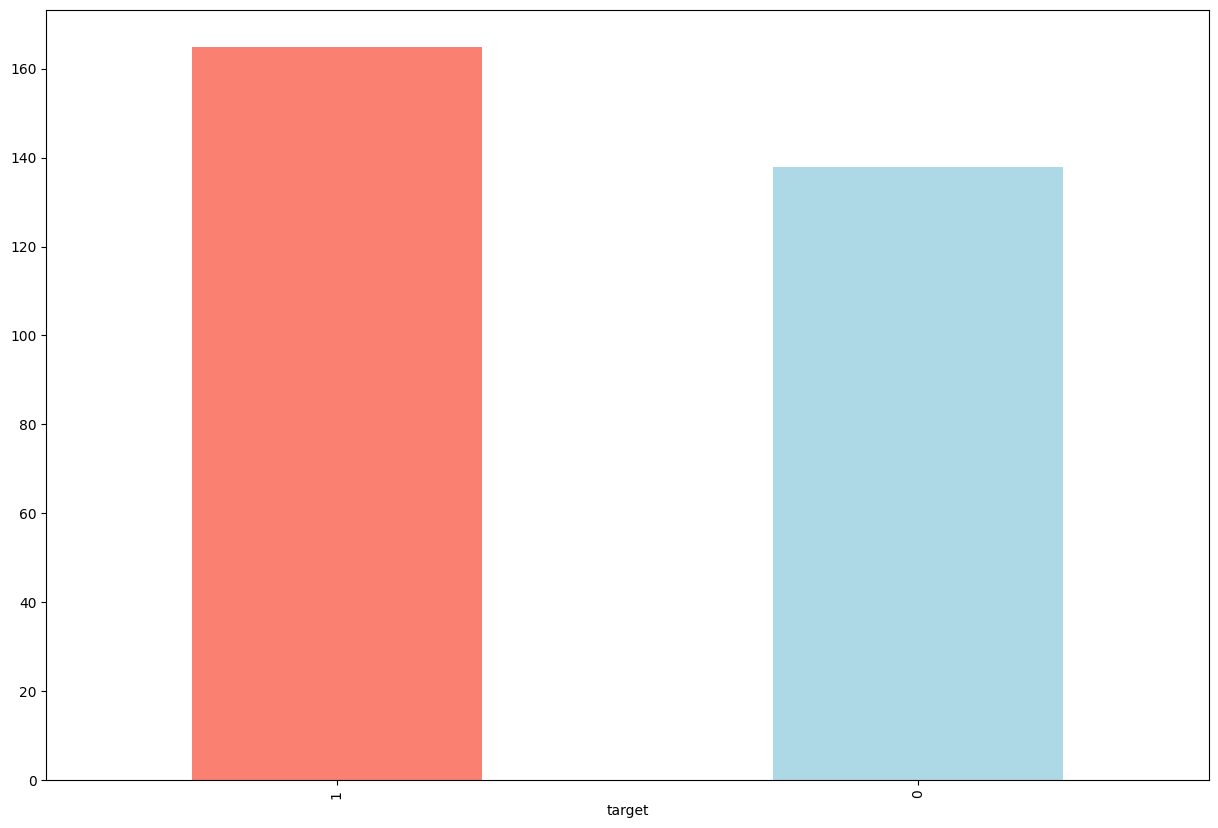

In [66]:
df['target'].value_counts().plot(figsize=(15,10),kind='bar',color=['salmon','lightblue']);

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [25]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [26]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart disease frequency according to sex

In [27]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [37]:
## compare target col with sex column
pd.crosstab(df.target,df.sex)

sex,0,1
target,,
0,24,114
1,72,93


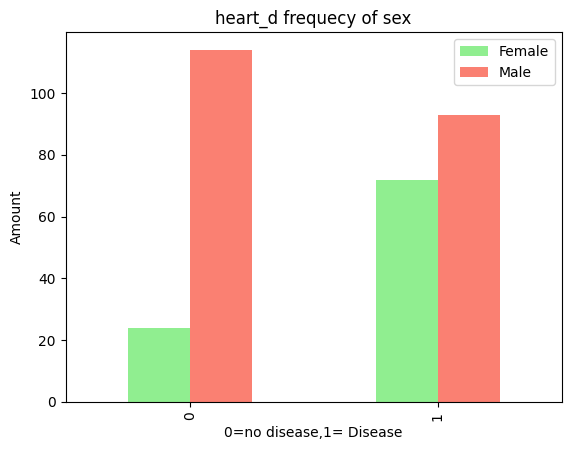

In [9]:
## create a plot of crosstab
pd.crosstab(df.target,df.sex).plot(kind='bar',color=['lightgreen',"salmon"])
plt.title("heart_d frequecy of sex")
plt.xlabel("0=no disease,1= Disease")
plt.ylabel("Amount")
plt.legend(["Female","Male"])


In [53]:
df.thalach.value_counts()

thalach
162    11
163     9
160     9
173     8
152     8
       ..
117     1
71      1
118     1
134     1
90      1
Name: count, Length: 91, dtype: int64

## Age vs Max_heart_rate

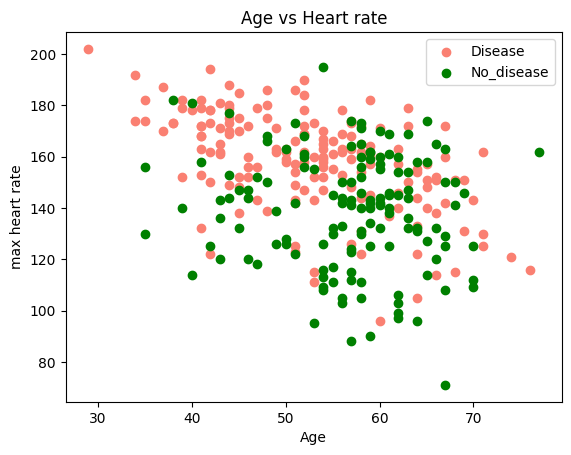

In [50]:
# pd.crosstab(df.age,df.thalach )
plt.scatter(df.age[df.target==1],
           df.thalach[df.target==1],
           color=['salmon'])
plt.scatter(df.age[df.target==0],
           df.thalach[df.target==0],
           color=['green'])
plt.title("Age vs Heart rate")
plt.xlabel("Age")
plt.ylabel("max heart rate")
plt.legend(['Disease','No_disease'])

[]

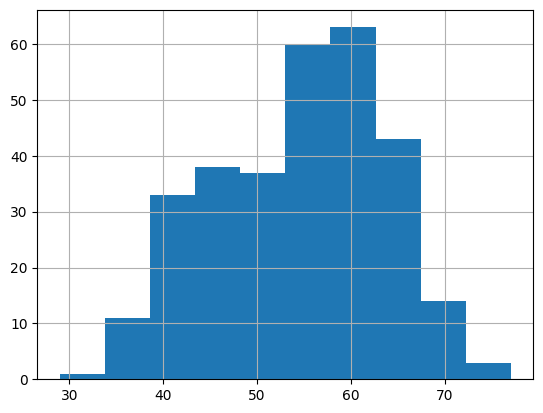

In [52]:
df['age'].hist().plot()

## heart pain vs disease
cp → Chest pain type
typical angina 
atypical angina
non-anginal pain
asymptomatic

In [54]:
pd.crosstab(df.cp,df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


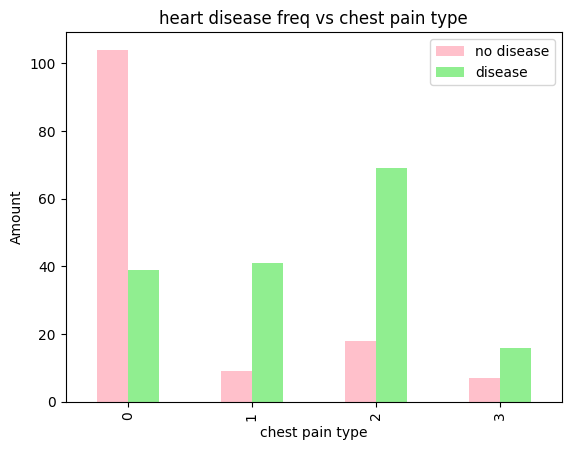

In [61]:
pd.crosstab(df.cp,df.target).plot(kind='bar',color=['pink','lightgreen'])
plt.title("heart disease freq vs chest pain type")
plt.xlabel("chest pain type")
plt.ylabel("Amount")
plt.legend(['no disease','disease'])

### 5.Modeling

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
## split data into x and y
x=df.drop("target",axis=1)
y=df['target']

In [5]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [7]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [5]:
# split Data into Training and testing 
np.random.seed(1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [15]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
62,52,1,3,118,186,0,0,190,0,0.0,1,0,1
127,67,0,2,152,277,0,1,172,0,0.0,2,1,2
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
287,57,1,1,154,232,0,0,164,0,0.0,2,1,2
108,50,0,1,120,244,0,1,162,0,1.1,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,68,1,2,180,274,1,0,150,1,1.6,1,0,3
255,45,1,0,142,309,0,0,147,1,0.0,1,3,3
72,29,1,1,130,204,0,0,202,0,0.0,2,0,2
235,51,1,0,140,299,0,1,173,1,1.6,2,0,3


In [16]:
y_train.shape

(242,)

## Now we got data and split into training and testing split its time to build model.
lets try 3 different models
1.Logistic Regression
2.RandomForestClassifier
3.KNeighborsClasssifier

In [13]:
## put models in dictionry
models={"Logistic Regression":LogisticRegression(),
       "RandomForestClassifier":RandomForestClassifier(),
       "KNN":KNeighborsClassifier()}

def fit_and_score(models,x_train,x_test,y_train,y_test):
    np.random.seed(1)
    #make dictionary to keep models score
    model_score={}
    ## loop through models
    for name,model in models.items():
        # fit model to data
        model.fit(x_train,y_train)
        # Evalute the models and append its score to model_score
        model_score[name]=model.score(x_test,y_test)
    return model_score    


In [14]:
model_score=fit_and_score(models=models,
                         x_train=x_train,
                         x_test=x_test,
                         y_train=y_train,
                         y_test=y_test)
model_score

C:\Users\Lenovo\Desktop\heart_disease\env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.7704918032786885,
 'RandomForestClassifier': 0.8032786885245902,
 'KNN': 0.5737704918032787}

In [6]:
np.random.seed(1)
model_1=LogisticRegression()
model_1.fit(x_train,y_train)
model_1.score(x_test,y_test)


C:\Users\Lenovo\Desktop\heart_disease\env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7704918032786885

In [8]:
%%time
np.random.seed(1)
model_2=RandomForestClassifier()
model_2.fit(x_train,y_train)
model_2.score(x_test,y_test)

CPU times: total: 375 ms
Wall time: 403 ms


0.8032786885245902

In [9]:
np.random.seed(1)
model_3=KNeighborsClassifier()
model_3.fit(x_train,y_train)
model_3.score(x_test,y_test)

0.5737704918032787

In [20]:
#MODEL COMPARISONM

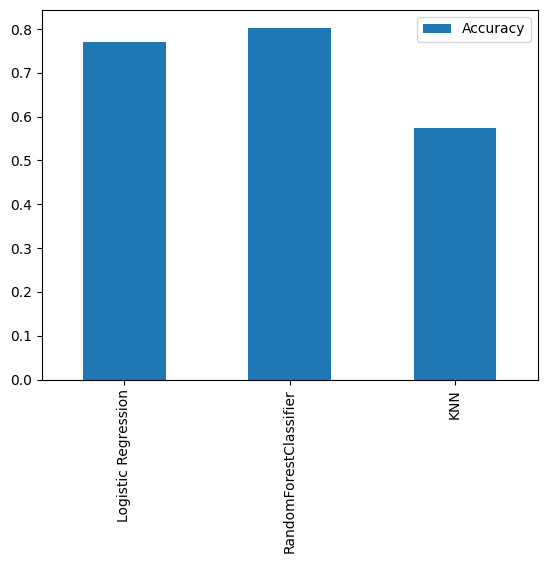

In [15]:
comparison=pd.DataFrame(model_score,
                       index=['Accuracy'])
comparison.T.plot.bar();

## Now we got our baseline models
we knows a models first predictions are not always what we should based our next steps off
whta should we do ?


# Lets look the following
hyperparameter tuning
2. feature importance
3.confusion matrix
4.cross_validation
5.precision
6.recall
7.f1 score
8.classification report
9.ROC curve
10.area under the curve

## HYPERPARAMETER TUNNING : LETS TUNE RANDOMIZEDSEARCHCV

WE ARE GOING TO TUNE 
1.LOGISTIC REGRESSION
2.RANDOMFORESTCLASSIFIER
# USING RANDOMIZED SEARCH CV

CREATE A HYPERPARAMETER GRID FOR LOGISTIC REGRESSIONM

In [12]:
log_grid={'C':np.logspace(-4,4,20),
        "solver":["liblinear"]}
# create hyperparameter grid for RFC
RFC_grid={"n_estimators":np.arange(10,1000,50),
         "max_depth":[None,5,10,20,30],
         "max_features":['sqrt','log2'],
         "min_samples_split":np.arange(10,100,10),
         "min_samples_leaf":np.arange(1,20,5)}



In [13]:
## Tune logisticRegression
np.random.seed(1)
log_model=RandomizedSearchCV(LogisticRegression(),
                             param_distributions=log_grid,
                             cv=5,n_iter=20,verbose=True)
# fit random hyperparameter sewarch model for LogisticRegression

log_model.fit(x_train,y_train)



Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegression()
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [24]:
log_model.best_params_


{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [25]:
log_model.score(x_test,y_test)

0.7704918032786885

now we tuned LogisticRegression lets do same for RFC

In [14]:
np.random.seed(42)
rfc_grid={"n_estimators":np.arange(10,1000,25),
         "max_depth":[None,3,5,10],
         "max_features":['sqrt','log2'],
         "min_samples_leaf":np.arange(10,50,5),
         "min_samples_split":np.arange(10,1000,50)}
rfc_model=RandomizedSearchCV(RandomForestClassifier(),
                            param_distributions=RFC_grid,
                             cv=5,n_iter=20,verbose=True)
rfc_model.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': array([ 1, 6, 11, 16]), 'min_samples_split': array([10, 20..., 70, 80, 90]), ...}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [15]:
rfc_model.score(x_test,y_test)


0.8032786885245902

In [67]:
a=rfc_model.score(x_test,y_test)
print(a*100,"%")

80.32786885245902 %


## Hyper parameter training using GridSearchCV

In [15]:
grid={'n_estimators':np.arange(100,1000,100),
     'max_depth':np.arange(10,100,50),
     'max_features':["sqrt"],
     # 'min_samples_leaf':np.arange(10,100,10)
     }
     
rf_model=GridSearchCV(RandomForestClassifier(),
                     param_grid=grid,
                     cv=5,verbose=2)
rf_model.fit(x_train,y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   0.5s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   0.4s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   0.5s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   0.4s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=200; total time=   0.9s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=200; total time=   0.7s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=200; total time=   0.7s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=200; total time=   0.7s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=200; total time=   0.7s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=300; total time=   1.3s
[CV] END ..max_depth=10, max_features=sqrt, n_es

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': array([10, 60]), 'max_features': ['sqrt'], 'n_estimators': array([100, 2...00, 800, 900])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,np.int64(200)


In [16]:
rf_model.score(x_test,y_test)

0.7540983606557377

In [10]:
log_grid={'C':np.logspace(-4,4,30),
         "solver":['liblinear']}
log_model=GridSearchCV(LogisticRegression(),
                      param_grid=log_grid,
                      cv=5,verbose=True)
log_model.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,LogisticRegression()
,param_grid,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [11]:
log_model.score(x_test,y_test)

0.7704918032786885

In [12]:
log_model.best_params_

{'C': np.float64(0.38566204211634725), 'solver': 'liblinear'}

## Evaluating our tuned machine learning classifier, beyond accuracy

1.ROC curve ans AUC score
2.confusion matrix
3.classification report
4.precision,recall,f1 score

In [26]:
y_preds1=rfc_model.predict(x_test)
y_preds1

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1])

In [27]:
y_preds2=log_model.predict(x_test)
y_preds2

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1])

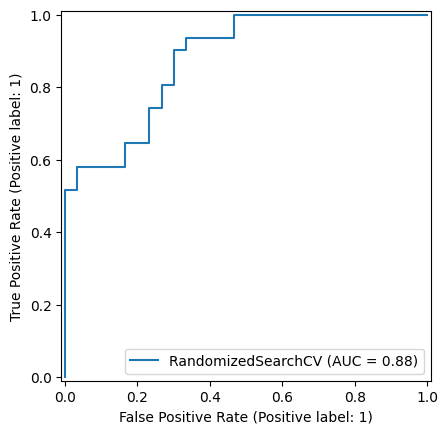

In [20]:
# plot roc curve and calculate AUC metric
RocCurveDisplay.from_estimator(rfc_model,x_test,y_test)

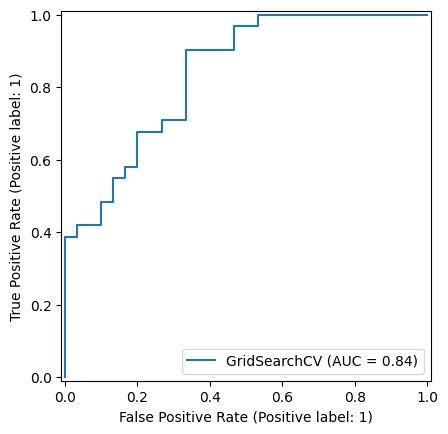

In [21]:
RocCurveDisplay.from_estimator(log_model,x_test,y_test)

In [25]:
## confusion matrix
print(confusion_matrix(y_test,y_preds))

[[21  9]
 [ 3 28]]


In [30]:
# RandomForestClassifier model
pd.crosstab(y_test,y_preds,
           rownames=['Actual'],
           colnames=['predicted'])

predicted,0,1
Actual,,
0,21,9
1,3,28


In [28]:
print(confusion_matrix(y_test,y_preds2))

[[20 10]
 [ 4 27]]


In [29]:
## Logistic Regresssion model
pd.crosstab(y_test,y_preds2,
           rownames=['Actual'],
           colnames=['predicted'])

predicted,0,1
Actual,,
0,20,10
1,4,27


* PRECISION & RECALL-is the ability of the classifier not to label as positive a sample that is negative, and recall is the ability of the classifier to find all the positive samples.
* F1-can be interpreted as a weighted harmonic mean of the precision and recall. 

now we got confusion matrix,roc curve and auc score

In [32]:
## classification report
print(classification_report(y_test,y_preds1))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78        30
           1       0.76      0.90      0.82        31

    accuracy                           0.80        61
   macro avg       0.82      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



In [33]:
print(classification_report(y_test,y_preds2))


              precision    recall  f1-score   support

           0       0.83      0.67      0.74        30
           1       0.73      0.87      0.79        31

    accuracy                           0.77        61
   macro avg       0.78      0.77      0.77        61
weighted avg       0.78      0.77      0.77        61



### Calculate Evaluaation matrix using cross validation- 

we are going to find precision ,f1 ,recall 

In [37]:
rfc_model.best_params_

{'n_estimators': np.int64(210),
 'min_samples_split': np.int64(20),
 'min_samples_leaf': np.int64(16),
 'max_features': 'sqrt',
 'max_depth': 10}

In [38]:
log_model.best_params_

{'C': np.float64(0.38566204211634725), 'solver': 'liblinear'}

In [42]:
# Create new classifier with best paramas
rfc_clf=RandomForestClassifier(n_estimators= np.int64(210),
 min_samples_split= np.int64(20),
 min_samples_leaf= np.int64(16),
 max_features= 'sqrt',
 max_depth= 10)


In [44]:
lr_clf=LogisticRegression(C= np.float64(0.38566204211634725), solver= 'liblinear')

In [54]:
# cross validate accuracy
np.random.seed(1)
cv_acc=cross_val_score(rfc_clf,x,y,cv=5,scoring='accuracy')
cv_acc=np.mean(cv_acc)
cv_acc


np.float64(0.8381420765027323)

In [55]:
## cross validated precision
cv_pre=cross_val_score(rfc_clf,x,y,cv=5,scoring='precision')
cv_pre=np.mean(cv_pre)
cv_pre

np.float64(0.8329834619308304)

In [58]:
## cross validated recall
cv_recall=cross_val_score(rfc_clf,x,y,cv=5,scoring='recall')
cv_recall=np.mean(cv_recall)
cv_recall

np.float64(0.8848484848484848)

In [59]:
## cross validated f1 score
cv_f1=cross_val_score(rfc_clf,x,y,cv=5,scoring='f1')
cv_f1=np.mean(cv_f1)
cv_f1

np.float64(0.8479896728412875)

<Axes: title={'center': 'cross validated classification metrics '}>

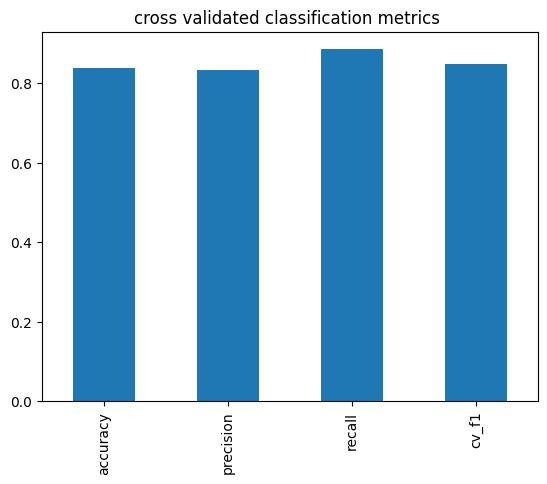

In [60]:
metrics=pd.DataFrame({"accuracy":cv_acc,
                     "precision":cv_pre,
                     "recall":cv_recall,
                     "cv_f1":cv_f1},
                    index=[0])
metrics.T.plot.bar(title="cross validated classification metrics ",legend=False)

### Feature Importance 
* is another way of asking which feature contributed most to the outcomes of the model and how did the contributed

In [62]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [20]:
## FIT an instance of LogisticREGRESSION
log_model.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [22]:
clf=LogisticRegression(C=0.23357214690901212,
                      solver='liblinear')
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.23357214690901212
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [23]:
## check coef_
clf.coef_

array([[-0.00180184, -1.13910988,  0.86472518, -0.01957873, -0.00250239,
         0.04538935,  0.42810526,  0.03269315, -0.62034513, -0.56075157,
         0.17068444, -0.56238545, -0.35650512]])

In [25]:
## mathch coef_ with features
features_dict=dict(zip(df.columns,list(clf.coef_[0])))
features_dict

{'age': np.float64(-0.0018018434787337337),
 'sex': np.float64(-1.1391098778558664),
 'cp': np.float64(0.8647251845096934),
 'trestbps': np.float64(-0.01957872847765905),
 'chol': np.float64(-0.002502385241695098),
 'fbs': np.float64(0.045389349313513516),
 'restecg': np.float64(0.42810525785125936),
 'thalach': np.float64(0.0326931468477076),
 'exang': np.float64(-0.6203451311368953),
 'oldpeak': np.float64(-0.5607515663194403),
 'slope': np.float64(0.17068443690726184),
 'ca': np.float64(-0.5623854450071508),
 'thal': np.float64(-0.3565051212687729)}

<Axes: >

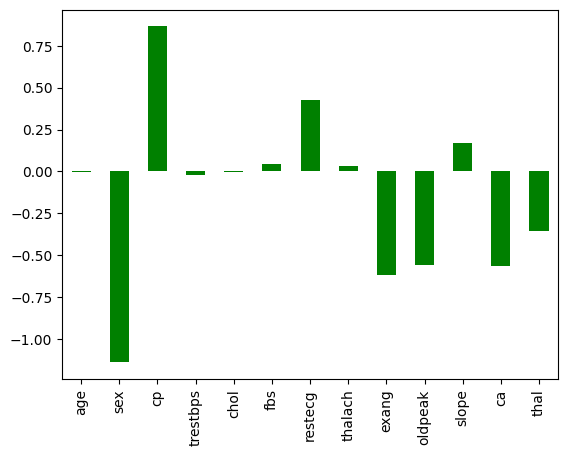

In [31]:
## visualize its importance
df=pd.DataFrame(features_dict,index=[0])
df.T.plot(kind='bar',legend=False,color=['green'])

In [38]:
pd.crosstab(df['sex'],df['target'])

target,0,1
sex,,
0,24,72
1,114,93


In [43]:
rfc_model.score(x_test,y_test)

0.8032786885245902

## 6.Experimentation
if you havenot hit your evaluation metrics yet...ask yourself...
* could u collect more data
* could i try more better model like CatBoost,XGBoost
* can i improve current model

In [44]:
## save and load model
from joblib import dump,load

In [46]:
dump(rfc_model,filename="heart_disease_prediction_model.ipynb")

['heart_disease_prediction_model.ipynb']

In [48]:
model=load(filename='heart_disease_prediction_model.ipynb')

In [49]:
y_p=model.predict(x_test)
np.mean(y_test==y_p)

np.float64(0.8032786885245902)